In [1]:
import h5ify
import matplotlib.pyplot as plt

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

from util import logtrapz

In [2]:
import numpy as np

In [7]:
posterior = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/strong/onemass-xphm-gwtc3-var5/posterior.h5')
posterior = dict(**posterior, **{k : v for k, v in posterior['samples'].items()})

In [8]:
posterior_var1 = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/strong/onemass-xphm-gwtc3-var1/posterior.h5')
posterior_var1 = dict(**posterior_var1, **{k : v for k, v in posterior_var1['samples'].items()})

In [23]:
prior = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/strong/onemass-xphm-gwtc3-var5/prior.h5')

mask = prior['variance'] < 1
prior_masked = dict(variance=prior['variance'][mask], **{k : v[mask] for k, v in prior['samples'].items()})

prior = dict(variance=prior['variance'], **{k : v for k, v in prior['samples'].items()})

In [43]:
for p in [prior, prior_masked, posterior, posterior_var1]:
    p['log10_variance'] = np.log10(p['variance'])

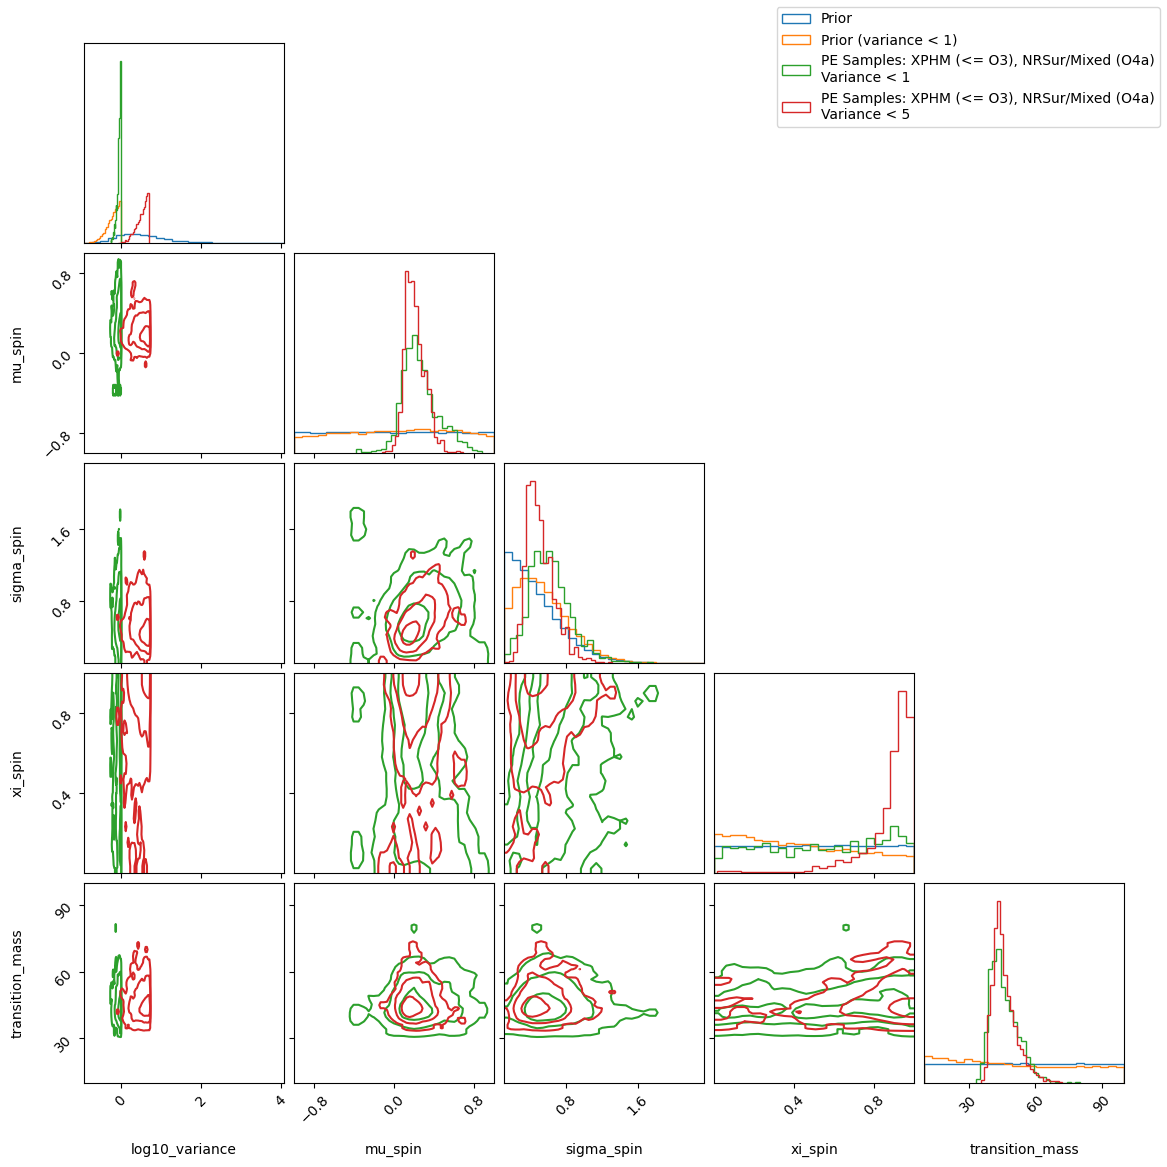

In [48]:
from util import plot_corner, plot_multiple

labels = [
    'log10_variance', 'mu_spin', 'sigma_spin', 'xi_spin', 'transition_mass'
]

fig = plot_corner(
    np.column_stack([ prior[k] for k in labels ]),
    plot_density=False,
    plot_datapoints=False,
    fill_contours=False,
    no_fill_contours=True,
    #levels=(0.5, 0.9),
    contour_kwargs=dict(linewidths=[0]),
    bins=25,
    color='C0',
    labels=labels
)

fig = plot_corner(
    np.column_stack([ prior_masked[k] for k in labels ]),
    plot_density=False,
    plot_datapoints=False,
    fill_contours=False,
    no_fill_contours=True,
    #levels=(0.5, 0.9),
    contour_kwargs=dict(linewidths=[0]),
    color='C1',
    fig=fig,
    bins=25
)

fig = plot_corner(
    np.column_stack([ posterior_var1[k] for k in labels ]),
    plot_density=False,
    plot_datapoints=False,
    fill_contours=False,
    no_fill_contours=True,
    #levels=(0.5, 0.9),
    color='C2',
    fig=fig,
    bins=25
)

fig = plot_corner(
    np.column_stack([ posterior[k] for k in labels ]),
    plot_density=False,
    plot_datapoints=False,
    fill_contours=False,
    no_fill_contours=True,
    #levels=(0.5, 0.9),
    color='C3',
    fig=fig,
    bins=25
)

from matplotlib.patches import Patch

fig.legend(
    handles=[
        Patch(edgecolor='C0', facecolor='none'),
        Patch(edgecolor='C1', facecolor='none'),
        Patch(edgecolor='C2', facecolor='none'),
        Patch(edgecolor='C3', facecolor='none'),
    ],
    labels=[
        'Prior',
        'Prior (variance < 1)',
        'PE Samples: XPHM (<= O3), NRSur/Mixed (O4a)\nVariance < 1',
        'PE Samples: XPHM (<= O3), NRSur/Mixed (O4a)\nVariance < 5'
    ]
)

fig.savefig('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/strong/onemass-xphm-gwtc3-var5/corner-tau-mtilde-var-compare.png')

In [4]:
from pixelpop.models.gwpop_models import trunc_gaussian
from pixelpop.models.gwpop_models import PowerlawPlusPeak_MassRatio
from models import BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth


def chi_trunc_gaussian(parameters, key=None):
    if key is None:
        key = ''
    elif key[0] != '_':
        key = f'_{key}'

    mu = parameters[f'mu_chi{key}']
    sigma = parameters[f'sigma_chi{key}']

    return trunc_gaussian(
        jnp.linspace(0, 1, 500),
        mu,
        sigma,
        lower=0,
        upper=1
    )


def log_masses(dataset, parameters, key=None):
    from pixelpop.models.gwpop_models import PowerlawPlusPeak_MassRatio

    if key is None:
        key = ''
    elif key[0] != '_':
        key = f'_{key}'

    lam_0 = parameters[f'lam{key}_0']
    lam_1 = parameters[f'lam{key}_1']
    if 'lam_2' not in parameters:
        lam_2 = 1 - lam_1 - lam_0
    else:
        lam_2 = parameters[f'lam{key}_2']

    lam_fractions = (lam_0, lam_1, lam_2)

    log_p_m1 = BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
        dataset['mass_1'],
        alpha_1=parameters[f'alpha_1{key}'],
        alpha_2=parameters[f'alpha_2{key}'],
        mlow_1=parameters[f'mlow_1{key}'],
        break_mass=parameters[f'break_mass{key}'],
        delta_m_1=parameters[f'delta_m_1{key}'],
        lam_fractions=lam_fractions,
        mpp_1=parameters[f'mpp_1{key}'],
        sigpp_1=parameters[f'sigpp_1{key}'],
        mpp_2=parameters[f'mpp_2{key}'],
        sigpp_2=parameters[f'sigpp_2{key}'],
        mmax=300.0,
        gaussian_mass_maximum=100.0
    )

    log_p_q = PowerlawPlusPeak_MassRatio(
        dataset,
        slope=parameters[f'beta{key}'],
        minimum=parameters[f'mlow_1{key}'],
        delta_m=parameters[f'delta_m_1{key}']
    )

    return log_p_m1, log_p_q



def log_model(parameters):
    tau = trunc_gaussian(
        jnp.linspace(-1, 1, 500),
        parameters['mu_spin'],
        parameters['sigma_spin'],
        lower=-1,
        upper=1
    )

    chi = chi_trunc_gaussian(parameters)
    chi_iso = chi_trunc_gaussian(parameters, key='iso')
    chi_high_iso = chi_trunc_gaussian(parameters, key='high_iso')

    m1 = jnp.linspace(3, 300, 500)
    q = jnp.linspace(0.1, 1, 500)

    mm, qq = jnp.meshgrid(m1, q, indexing='ij')

    zeta = parameters.get('zeta', 0)
    dataset = dict(mass_1=mm, mass_ratio=qq)

    if 'transition_mass' in parameters:
        mtilde = parameters['transition_mass']
        zeta = jax.scipy.special.expit(mm - mtilde)

    log_p_m1, log_p_q_given_m1 = log_masses(dataset, parameters)
    log_p_m1_iso, log_p_q_given_m1_iso = log_masses(
        dataset, parameters, key='iso'
    )

    # marginalize over m1 ... incl. zeta that depends on m1!
    log_p_q = logtrapz(
        jnp.log(1 - zeta) + log_p_m1 + log_p_q_given_m1,
        m1,
        axis=0
    )

    log_p_q_iso = logtrapz(
        jnp.log(1 - zeta) + log_p_m1_iso + log_p_q_given_m1_iso,
        m1,
        axis=0
    )

    log_p_q_high_iso = logtrapz(
        jnp.log(zeta) + log_p_m1_iso + log_p_q_given_m1_iso,

    )

    zeta = zeta[:, 0]

    return dict(
        zeta=zeta,
        cos_tilt=tau,
        chi=chi,
        chi_iso=chi_iso,
        chi_high_iso=chi_high_iso,
        mass_1=jnp.log(1 - zeta) + log_p_m1[:, 0],
        mass_1_iso=jnp.log(1 - zeta) + log_p_m1_iso[:, 0],
        mass_1_high_iso=jnp.log(zeta) + log_p_m1_iso[:, 0],
        mass_ratio=log_p_q,
        mass_ratio_iso=log_p_q_iso,
        mass_ratio_high_iso=log_p_q_high_iso
    )

/home/noah.wolfe/.conda/envs/just-for-kicks/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
datadir = '../../data/inference/strong'
posterior = h5ify.load(f'{datadir}/twomass/posterior.h5')

In [51]:
posterior.keys()

dict_keys(['ln_lkl', 'ln_pdet', 'ln_pdet_variance', 'pe_variance', 'samples', 'variance'])

In [5]:
from util import scan

ppds = scan(log_model)(posterior['samples'])

NameError: name 'posterior' is not defined

In [ ]:
h5ify.save(f'{datadir}/twomass/ppds.h5', ppds)

In [8]:
ppds = h5ify.load(f'{datadir}/twomass/ppds.h5')

In [10]:
import numpy as np

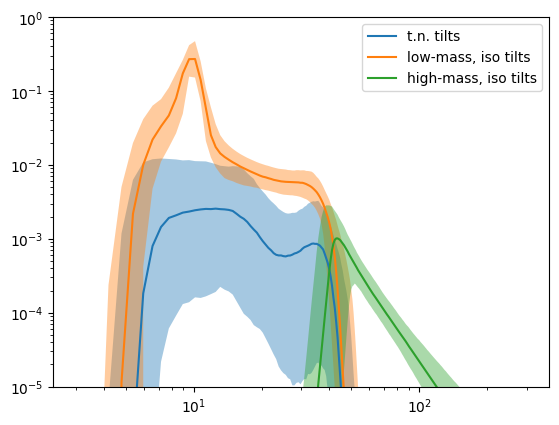

In [14]:
fig, ax = plt.subplots()

param = 'mass_1'
xs = jnp.linspace(3, 300, 500)

for i, key in enumerate(['', 'iso', 'high_iso']):
    if key == '':
        weight = posterior['samples']['xi_spin'][:, None]
        label = 't.n. tilts'
    elif key == 'iso':
        weight = 1 - posterior['samples']['xi_spin'][:, None]
        label = 'low-mass, iso tilts'
    else:
        weight = 1
        label = 'high-mass, iso tilts'

    if key != '':
        key = f'_{key}'

    prob = weight * jnp.exp(ppds[f'{param}{key}'])
    
    med = jnp.median(prob, axis=0)
    q05 = jnp.quantile(prob, 0.05, axis=0)
    q95 = jnp.quantile(prob, 0.95, axis=0)

    ax.plot(xs, med, color=f'C{i}', label=label)
    ax.fill_between(xs, q05, q95, alpha=0.4, color=f'C{i}', lw=0)

ax.loglog();

ax.set_ylim(1e-5, 1e0)

ax.legend();

fig.savefig(f'{datadir}/twomass/ppds/mass1.png')

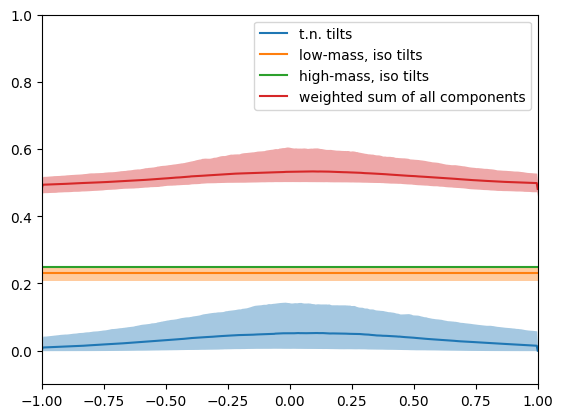

In [23]:
fig, ax = plt.subplots()

param = 'cos_tilt'
xs = jnp.linspace(-1, 1, 500)

probs = []

for i, key in enumerate(['', 'iso', 'high_iso']):
    if key == '':
        weight = posterior['samples']['xi_spin'][:, None]
        label = 't.n. tilts'
    elif key == 'iso':
        weight = 1 - posterior['samples']['xi_spin'][:, None]
        label = 'low-mass, iso tilts'
    else:
        weight = 1
        label = 'high-mass, iso tilts'

    if key != '':
        key = f'_{key}'

    if key == '':
        prob = weight * jnp.exp(ppds[f'{param}{key}'])
    elif key in ['_iso', '_high_iso']:
        prob = weight * jnp.ones((988, 500)) / 4

    probs.append(prob)

    med = jnp.median(prob, axis=0)
    q05 = jnp.quantile(prob, 0.05, axis=0)
    q95 = jnp.quantile(prob, 0.95, axis=0)

    ax.plot(xs, med, color=f'C{i}', label=label)
    ax.fill_between(xs, q05, q95, alpha=0.4, color=f'C{i}', lw=0)

probs = jnp.array(probs)
probs = jnp.sum(probs, axis=0)

med = jnp.median(probs, axis=0)
q05 = jnp.quantile(probs, 0.05, axis=0)
q95 = jnp.quantile(probs, 0.95, axis=0)

ax.plot(xs, med, color=f'C3', label='weighted sum of all components')
ax.fill_between(xs, q05, q95, alpha=0.4, color=f'C3', lw=0)

ax.set_ylim(-0.1, 1.0)
ax.set_xlim(-1, 1)

ax.legend()

fig.savefig(f'{datadir}/twomass/ppds/costilt.png')

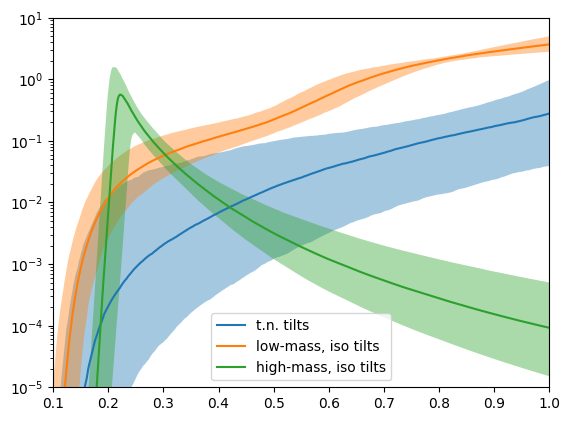

In [16]:
fig, ax = plt.subplots()

param = 'mass_ratio'
xs = jnp.linspace(0.1, 1, 500)

for i, key in enumerate(['', 'iso', 'high_iso']):
    if key == '':
        weight = posterior['samples']['xi_spin'][:, None]
        label = 't.n. tilts'
    elif key == 'iso':
        weight = 1 - posterior['samples']['xi_spin'][:, None]
        label = 'low-mass, iso tilts'
    else:
        weight = 1
        label = 'high-mass, iso tilts'

    if key != '':
        key = f'_{key}'

    prob = weight * jnp.exp(ppds[f'{param}{key}'])
    med = jnp.median(prob, axis=0)
    q05 = jnp.quantile(prob, 0.05, axis=0)
    q95 = jnp.quantile(prob, 0.95, axis=0)

    ax.plot(xs, med, color=f'C{i}', label=label)
    ax.fill_between(xs, q05, q95, alpha=0.4, color=f'C{i}', lw=0)

ax.set_yscale('log');

ax.set_ylim(1e-5, 1e1)
ax.set_xlim(0.1, 1)

ax.legend()

fig.savefig(f'{datadir}/twomass/ppds/mass_ratio.png')

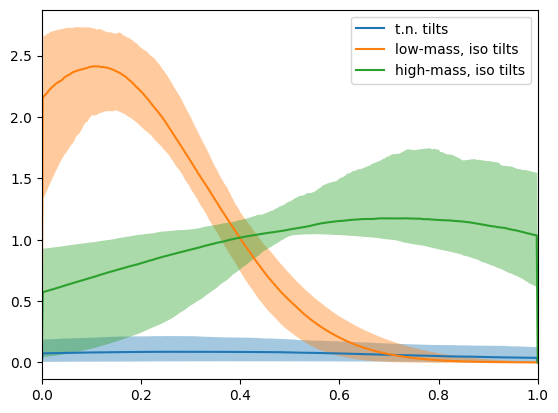

In [19]:
fig, ax = plt.subplots()

param = 'chi'
xs = jnp.linspace(0, 1, 500)

for i, key in enumerate(['', 'iso', 'high_iso']):
    if key == '':
        weight = posterior['samples']['xi_spin'][:, None]
        label = 't.n. tilts'
    elif key == 'iso':
        weight = 1 - posterior['samples']['xi_spin'][:, None]
        label = 'low-mass, iso tilts'
    else:
        weight = 1
        label = 'high-mass, iso tilts'

    if key != '':
        key = f'_{key}'

    prob = weight * jnp.exp(ppds[f'{param}{key}'])
    med = jnp.median(prob, axis=0)
    q05 = jnp.quantile(prob, 0.05, axis=0)
    q95 = jnp.quantile(prob, 0.95, axis=0)

    ax.plot(xs, med, color=f'C{i}', label=label)
    ax.fill_between(xs, q05, q95, alpha=0.4, color=f'C{i}', lw=0)

#ax.set_yscale('log');

#ax.set_ylim(1e-5, 1e1)
ax.set_xlim(0, 1)

ax.legend()

fig.savefig(f'{datadir}/twomass/ppds/chi.png')

In [2]:
prior = h5ify.load('./test/prior.h5')

In [7]:
prior.keys()

dict_keys(['ln_lkl', 'ln_pdet', 'ln_pdet_variance', 'pe_variance', 'samples', 'variance'])

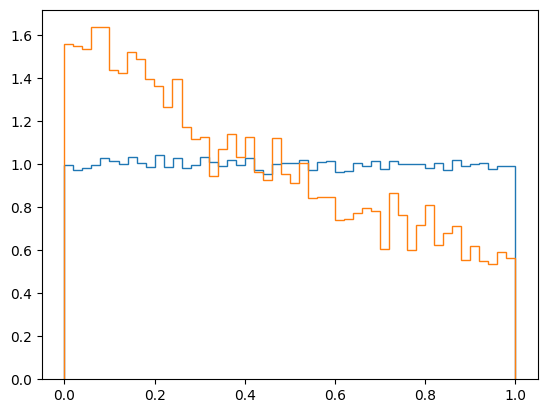

In [3]:
mask = prior['variance'] < 1
xs = prior['samples']['xi_spin']

fig, ax = plt.subplots()
ax.hist(xs, histtype='step', bins=50, density=True)
ax.hist(
    xs[mask],
    histtype='step',
    bins=50,
    density=True
);